# Modelo LDR
$$G=AE^\gamma$$

- $G$: conductancia
- $E$: idealmente iluminancia. En este caso es la intensidad relativa de cada LED
    - $E = c \in [0,255]$
- $A,\,\gamma$: variables

# Resolución por minimización de cuadrados

Se toman $n$ medidas de la conductancia $G$ a intensidades $c$ conocidas para cada color.

$$
Y = 
\begin{bmatrix}
G_1 \\
G_2 \\
\vdots \\
G_N
\end{bmatrix}
\qquad
A = 
\begin{bmatrix}
1 & \ln(c_1) \\
1 & \ln(c_2) \\
1 & \ln(c_N) \\
\end{bmatrix}
\qquad
\beta = 
\begin{bmatrix}
\alpha_1 \\
\alpha_2 \\
\vdots \\
\alpha_M \\
\end{bmatrix}
$$


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Vref = 3.3
Vdd = 5

In [6]:
dfR = pd.read_json("measurements_R_2.json").set_index("index")
dfR = dfR.drop("data", axis="columns")
dfR = dfR.rename(columns={"mean": "adc"})
dfR.head()

,channel,intensity,adc,Rf
index,,,,
0,R,0,3502.100,100
1,R,2,3715.275,10
2,R,3,3552.375,10
3,R,4,3339.325,10
4,R,5,3156.000,10


Text(0, 0.5, 'Código ADC')

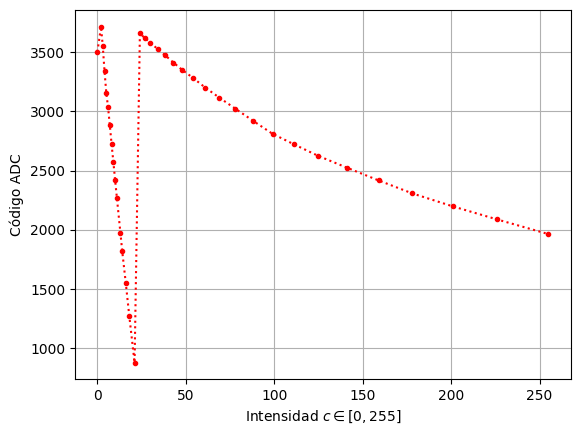

In [5]:
plt.plot("intensity", "adc", data=dfR, marker=".", linestyle="dotted", color="red")
plt.grid()
plt.xlabel(r"Intensidad $c \in [0,255]$")
plt.ylabel("Código ADC")

In [8]:
dfR["Vo"] = dfR["adc"] * Vref / 4095 
dfR["G"] = (Vref - dfR["Vo"]) / (dfR["Rf"]*(Vdd-Vref))

dfR.tail()

,channel,intensity,adc,Rf,Vo,G
index,,,,,,
32,R,159,2416.650,1,1.947484,0.795598
33,R,178,2307.450,1,1.859484,0.847363
34,R,201,2197.475,1,1.770859,0.899495
35,R,226,2087.450,1,1.682194,0.951651
36,R,255,1963.675,1,1.582449,1.010324


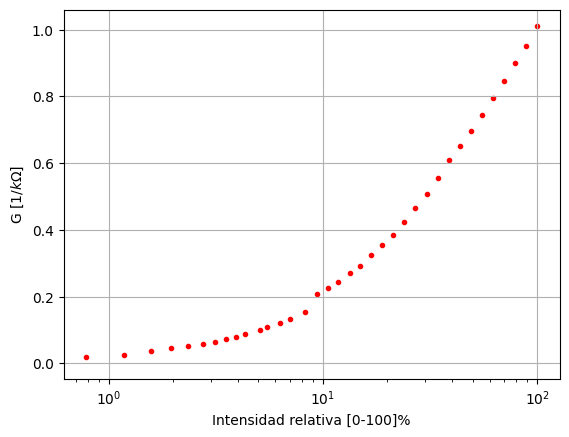

In [18]:
plt.scatter(dfR["intensity"]/255*100, dfR["G"], marker=".", color="red")
plt.xscale('log')
plt.ylabel(r"G $[1/k\Omega]$")
plt.xlabel(r"Intensidad relativa [0-100]%")
plt.grid()

In [19]:
# least squares
# b = Ax
b, c = (
    np.log(dfR.loc[dfR["intensity"] > 0, "G"]),
    dfR.loc[dfR["intensity"] > 0, "intensity"]
)

A = np.column_stack((np.ones(len(c)), np.log(c)))
A.shape

(36, 2)

In [20]:
x = np.linalg.lstsq(A, b)[0]
x

array([-4.464677  ,  0.85270658])

In [21]:
Ka_R = np.exp(x[0])
gamma_R = x[1]

Ka_R, gamma_R

(np.float64(0.011508412425650682), np.float64(0.8527065806062964))

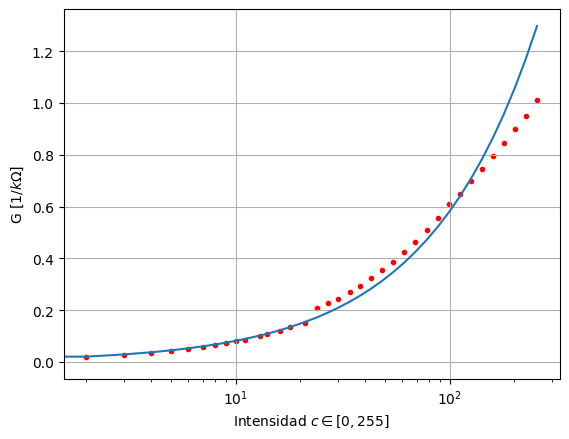

In [22]:
plt.scatter(dfR["intensity"], dfR["G"], marker=".", color="red")
plt.xscale('log')

plt.semilogx(dfR["intensity"], Ka_R*np.pow(dfR["intensity"], gamma_R))

plt.ylabel(r"G $[1/k\Omega]$")
plt.xlabel(r"Intensidad $c \in [0,255]$")
plt.grid()

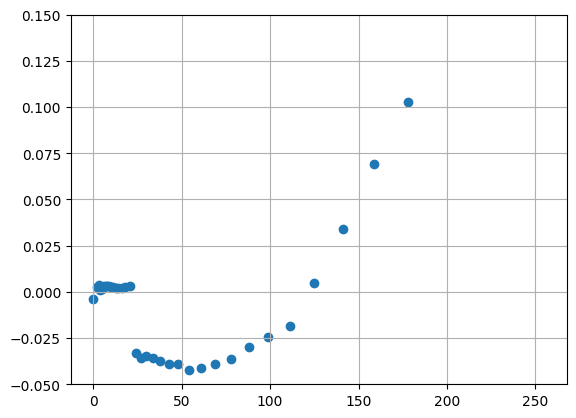

In [38]:
estimate = Ka_R*np.pow(dfR["intensity"], gamma_R)

plt.scatter(dfR["intensity"], estimate-dfR["G"])

plt.ylim((-0.05, 0.15))
plt.grid()

# Canal G

In [54]:
dfG = pd.read_json("measurements_G_2.json").set_index("index")
dfG = dfG.drop("data", axis="columns")
dfG = dfG.rename(columns={"mean": "adc"})
dfG.tail()

,channel,intensity,adc,Rf
index,,,,
32,G,159,3543.975,1
33,G,178,3503.150,1
34,G,201,3457.875,1
35,G,226,3410.800,1
36,G,255,3361.325,1


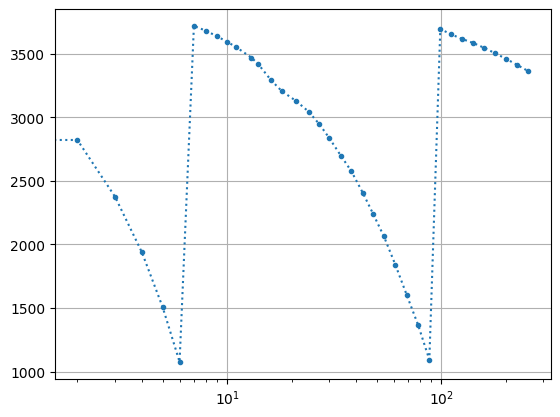

In [55]:
plt.plot("intensity", "adc", data=dfG, marker=".", linestyle="dotted")
plt.grid()
plt.xscale('log')

In [56]:
dfG["Vo"] = dfG["adc"] * Vref / 4095 
dfG["G"] = (Vref - dfG["Vo"]) / (dfG["Rf"]*(Vdd-Vref))
dfG.tail()

,channel,intensity,adc,Rf,Vo,G
index,,,,,,
32,G,159,3543.975,1,2.855951,0.261206
33,G,178,3503.150,1,2.823051,0.280558
34,G,201,3457.875,1,2.786566,0.302020
35,G,226,3410.800,1,2.748630,0.324335
36,G,255,3361.325,1,2.708760,0.347788


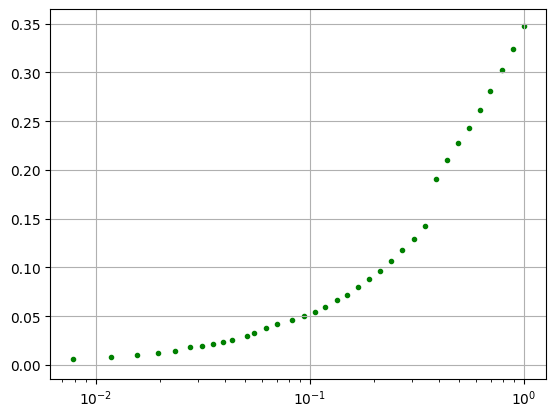

In [57]:
plt.scatter(dfG["intensity"]/255, dfG["G"], marker=".", color="green")
plt.xscale("log")
plt.grid()

In [58]:
# least squares
# b = Ax
b, c = (
    np.log(dfG.loc[dfG["intensity"] > 0, "G"]),
    dfG.loc[dfG["intensity"] > 0, "intensity"]
)

A = np.column_stack((np.ones(len(c)), np.log(c)))
A.shape

(36, 2)

In [59]:
x = np.linalg.lstsq(A, b)[0]
x

array([-5.72885931,  0.85973951])

In [60]:
Ka_G = np.exp(x[0])
gamma_G = x[1]

Ka_G, gamma_G

(np.float64(0.0032507832523976554), np.float64(0.8597395131749697))

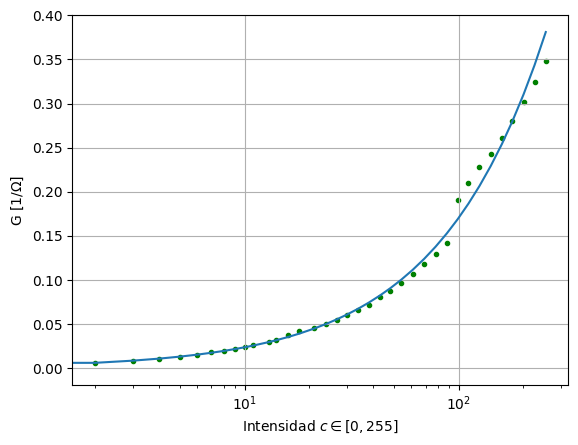

In [61]:
plt.scatter(dfG["intensity"], dfG["G"], marker=".", color="green")
plt.xscale('log')

plt.semilogx(dfG["intensity"], Ka_G*np.pow(dfG["intensity"], gamma_G))

plt.ylabel(r"G $[1/\Omega]$")
plt.xlabel(r"Intensidad $c \in [0,255]$")
plt.grid()

# Canal B

In [66]:
dfB = pd.read_json("measurements_B_2.json").set_index("index")
dfB = dfB.drop("data", axis="columns")
dfB = dfB.rename(columns={"mean": "adc"})
dfB.tail()

,channel,intensity,adc,Rf
index,,,,
32,B,159,3630.875,1
33,B,178,3600.525,1
34,B,201,3569.450,1
35,B,226,3534.425,1
36,B,255,3492.500,1


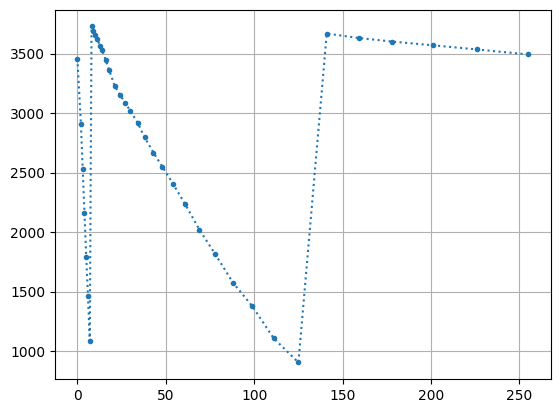

In [67]:
plt.plot("intensity", "adc", data=dfB, marker=".", linestyle="dotted")
plt.grid()

In [68]:
dfB["Vo"] = dfB["adc"] * Vref / 4095 
dfB["G"] = (Vref - dfB["Vo"]) / (dfB["Rf"]*(Vdd-Vref))
dfB.tail()

,channel,intensity,adc,Rf,Vo,G
index,,,,,,
32,B,159,3630.875,1,2.925980,0.220012
33,B,178,3600.525,1,2.901522,0.234399
34,B,201,3569.450,1,2.876480,0.249129
35,B,226,3534.425,1,2.848255,0.265733
36,B,255,3492.500,1,2.814469,0.285607


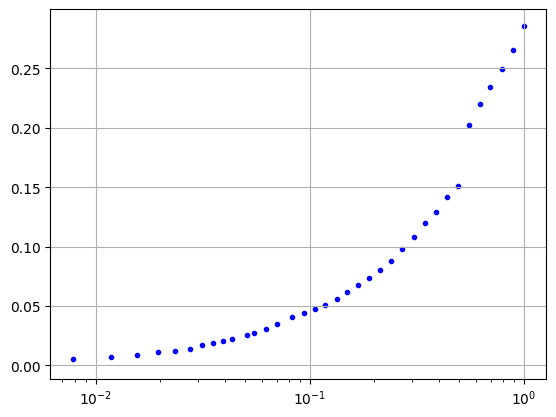

In [69]:
plt.scatter(dfB["intensity"]/255, dfB["G"], marker=".", color="blue")
plt.xscale("log")
plt.grid()

In [70]:
# least squares
# b = Ax
b, c = (
    np.log(dfB.loc[dfB["intensity"] > 0, "G"]),
    dfB.loc[dfB["intensity"] > 0, "intensity"]
)

A = np.column_stack((np.ones(len(c)), np.log(c)))
A.shape

(36, 2)

In [71]:
x = np.linalg.lstsq(A, b)[0]
x

array([-5.80117042,  0.82832336])

In [72]:
Ka_B = np.exp(x[0])
gamma_B = x[1]

Ka_B, gamma_B

(np.float64(0.0030240133142661603), np.float64(0.8283233614433873))

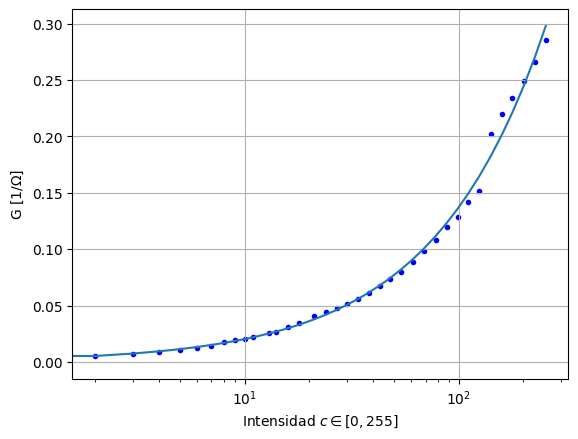

In [73]:
plt.scatter(dfB["intensity"], dfB["G"], marker=".", color="blue")
plt.xscale('log')

plt.semilogx(dfB["intensity"], Ka_B*np.pow(dfB["intensity"], gamma_B))

plt.ylabel(r"G $[1/\Omega]$")
plt.xlabel(r"Intensidad $c \in [0,255]$")
plt.grid()